# Philosophy of AI and the Turing Test

## 📚 Learning Objectives

By completing this notebook, you will:
- Explain the Turing test and main philosophical debates
- Discuss strengths and limitations of behavioral definitions of intelligence

## 🔗 Where this fits

**Builds on:** Unit 1, lesson 04 "Intelligent Agents and Rationality" — behaviour is the yardstick there too, which is exactly what the Turing test bets on.

**Used later in:** Course 06 (AIAT 116) — Unit 1, where behavioural definitions of intelligence run into ethical frameworks.

---


## 🎯 Three machines that fooled people, sixty years apart

**1966 — ELIZA.** Joseph Weizenbaum described ELIZA in *Communications of the
ACM* in January 1966: a pattern-matching program written at MIT whose DOCTOR
script reflected a user's sentences back as questions ("I am unhappy" →
"How long have you been unhappy?"). It had no memory, no model of the
conversation and no knowledge of anything. Weizenbaum was disturbed to find that
people who knew exactly how it worked still confided in it and asked to be left
alone with it. The pull is now named after the program: the **ELIZA effect**.

**2014 — Eugene Goostman.** At a Turing test event at the Royal Society in
London on 7 June 2014, a chatbot playing a 13-year-old Ukrainian boy convinced
**33% of the judges** in five-minute conversations, and the organisers announced
that the Turing test had been passed. The critics' objection was about the
*persona*, not the code: a foreign 13-year-old is expected to have shaky grammar,
patchy knowledge and a habit of changing the subject, so the character absorbed
every tell the program would otherwise have produced.

**2025 — GPT-4.5.** Jones and Bergen ran a controlled three-party test (judge,
human witness, machine witness, five-minute conversations) and reported that
GPT-4.5, **when prompted to adopt a humanlike persona**, was picked as the human
**73% of the time** — more often than the actual human was. Without the persona
prompt the win rate fell sharply. Sixty years apart, the same lever: the costume,
not the mind.

### What the Turing test was actually for

Turing's 1950 paper opens by refusing the question "can machines think?" as too
vague to answer, and replaces it with an *operational* one you can run: can a
judge tell? That move is the whole contribution. Without it, "is this system
intelligent?" is an argument about words that no experiment can settle; with it,
you get a procedure, a score, and — as the three cases above show — an argument
about whether the procedure measures what you wanted.


# Philosophy of AI and the Turing Test
## AIAT 111 - Introduction to AI

---

## 📚 Learning Objectives

This notebook demonstrates key concepts through hands-on examples.

By completing this notebook, you will:
- Understand the philosophical foundations of AI
- Learn about Alan Turing's contributions to AI
- Understand the Turing Test and its implications
- Explore objections and debates about AI
- Analyze the relationship between intelligence and computation

---

## 🔗 Prerequisites

- ✅ Python 3.8+ installed
- ✅ Basic understanding of AI concepts
- ✅ Interest in philosophical questions about intelligence

---

## Real-World Context

You are researching the philosophical foundations of AI to understand what it means for a machine to be "intelligent" and how we can measure this. This understanding is crucial for developing ethical AI systems and setting realistic expectations for AI capabilities.

---

## 📥 Inputs & 📤 Outputs

**Inputs:** What we use in this notebook

- Libraries and concepts as introduced in this notebook; see prerequisites and code comments.

**Outputs:** What you'll see when you run the cells

- Printed results, figures, and summaries as shown when you run the cells.

---

In [1]:
# Setup
import random
import time

print("=" * 60)
print("Philosophy of AI and the Turing Test")
print("=" * 60)
print("\n✅ Setup complete!")

Philosophy of AI and the Turing Test

✅ Setup complete!


## 1. Alan Turing's Contributions

Alan Turing (1912-1954) made foundational contributions to AI:

### Key Contributions:
1. **Turing Machine (1936)**: Theoretical model of computation
2. **Turing Test (1950)**: Test for machine intelligence
3. **Computational Theory of Mind**: Mind as computation

### The Turing Test (1950)
- **Question**: "Can machines think?"
- **Test**: If a human judge cannot distinguish between machine and human responses, the machine passes
- **Implications**: Behavior-based definition of intelligence


In [2]:
# A miniature Turing Test: a keyword-matching chatbot answers a few questions.
# The point is not the code — it is asking whether fooling a human judge equals intelligence.
# Simple Turing Test Simulation
class SimpleChatbot:
    """Simple chatbot for Turing Test demonstration"""
    def __init__(self):
        self.responses = {
            'hello': ['Hello!', 'Hi there!', 'Greetings!'],
            'how are you': ['I am doing well, thank you!', 'Great, thanks for asking!'],
            'what is ai': ['AI is the simulation of human intelligence by machines.', 
                          'AI involves creating systems that can perform tasks requiring intelligence.'],
            'goodbye': ['Goodbye!', 'See you later!', 'Farewell!']
        }
    
    # Pick a canned reply whose trigger keyword appears in the user's message — no understanding involved.
    def respond(self, user_input):
        """Generate response based on user input"""
        user_input_lower = user_input.lower().strip()
        
        # Simple keyword matching
        for key, responses in self.responses.items():
            if key in user_input_lower:
                return random.choice(responses)
        
        # Default response
        return "That's interesting. Can you tell me more?"

# Test the chatbot
# Hold a short conversation and judge for yourself: could this pass as human?
bot = SimpleChatbot()
print("Chatbot: Hello! I'm a simple chatbot. Ask me something!")
print("\nExample interactions:")
print(f"User: Hello\nBot: {bot.respond('Hello')}")
print(f"User: What is AI?\nBot: {bot.respond('What is AI?')}")
print(f"User: How are you?\nBot: {bot.respond('How are you?')}")

print("\n" + "=" * 60)
print("Turing Test Concept:")
print("If you couldn't tell this was a machine, it might pass!")
print("=" * 60)

Chatbot: Hello! I'm a simple chatbot. Ask me something!

Example interactions:
User: Hello
Bot: Greetings!
User: What is AI?
Bot: AI is the simulation of human intelligence by machines.
User: How are you?
Bot: Great, thanks for asking!

Turing Test Concept:
If you couldn't tell this was a machine, it might pass!


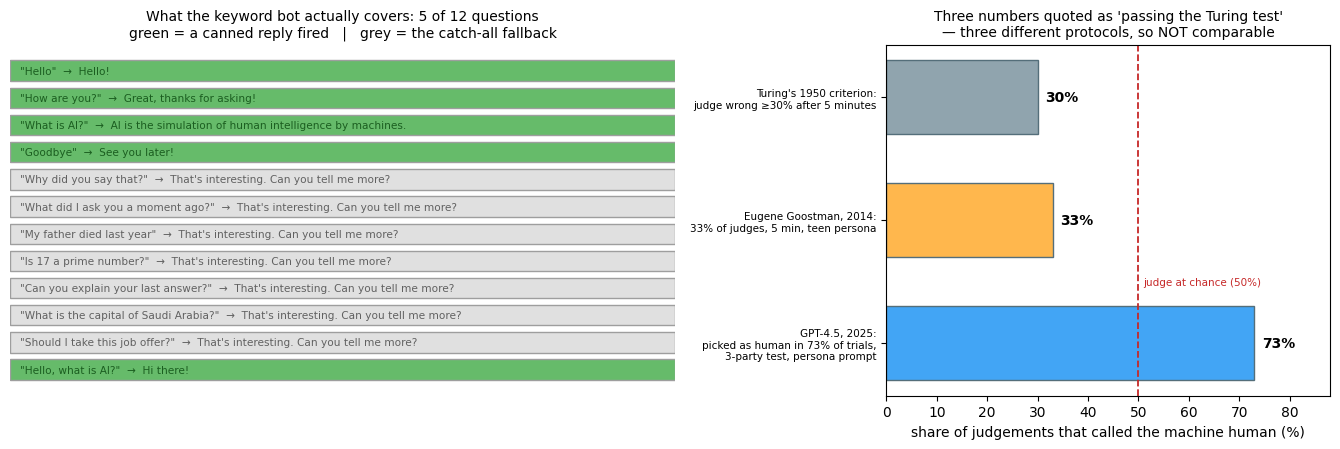

Canned reply fired for 5/12 questions; the other 7 got the identical fallback sentence.
The bot's entire knowledge is 4 keywords: ['hello', 'how are you', 'what is ai', 'goodbye']

Note "Hello, what is AI?" — the first keyword in the table wins, so the bot
answered the greeting and ignored the question: "Hi there!"


In [3]:
# ── Measure the bot instead of admiring it ───────────────────────────────────
# WHAT: send twelve ordinary questions to the SAME `bot` object built above and record,
#       for each one, whether a canned reply fired or the catch-all fallback did.
#       Then place the three "pass rates" this notebook quotes on one axis.
# WHY:  three well-chosen questions make the bot look conversational. Twelve show you
#       the size of the machine behind the conversation — which is the ELIZA effect,
#       measured rather than described.
import matplotlib.pyplot as plt

FALLBACK = "That's interesting. Can you tell me more?"
probes = ["Hello", "How are you?", "What is AI?", "Goodbye",
          "Why did you say that?", "What did I ask you a moment ago?",
          "My father died last year", "Is 17 a prime number?",
          "Can you explain your last answer?", "What is the capital of Saudi Arabia?",
          "Should I take this job offer?", "Hello, what is AI?"]

results = [(q, bot.respond(q)) for q in probes]
matched = sum(1 for _, reply in results if reply != FALLBACK)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13.5, 4.6),
                               gridspec_kw={'width_ratios': [1.5, 1]})

# LEFT: coverage of the toy chatbot
for y, (question, reply) in enumerate(results):
    hit = reply != FALLBACK
    ax1.barh(y, 1, color='#66bb6a' if hit else '#e0e0e0', edgecolor='#9e9e9e', height=0.75)
    ax1.text(0.015, y, f'"{question}"  →  {reply}', va='center', fontsize=7.6,
             color='#1b5e20' if hit else '#616161')
ax1.set_yticks([])
ax1.set_xticks([])
ax1.set_xlim(0, 1)
ax1.invert_yaxis()
ax1.set_title(f"What the keyword bot actually covers: {matched} of {len(results)} questions\n"
              "green = a canned reply fired   |   grey = the catch-all fallback", fontsize=10)
for side in ['top', 'right', 'left', 'bottom']:
    ax1.spines[side].set_visible(False)

# RIGHT: the three figures this notebook quotes, each with its own protocol
claims = [("Turing's 1950 criterion:\njudge wrong ≥30% after 5 minutes", 30, '#90a4ae'),
          ("Eugene Goostman, 2014:\n33% of judges, 5 min, teen persona", 33, '#ffb74d'),
          ("GPT-4.5, 2025:\npicked as human in 73% of trials,\n3-party test, persona prompt", 73, '#42a5f5')]
positions = range(len(claims))
ax2.barh(list(positions), [v for _, v, _ in claims],
         color=[c for _, _, c in claims], edgecolor='#546e7a', height=0.6)
for y, (_, value, _) in zip(positions, claims):
    ax2.text(value + 1.5, y, f"{value}%", va='center', fontsize=10, fontweight='bold')
ax2.axvline(50, color='#c62828', linestyle='--', linewidth=1.3)
ax2.text(51, 1.5, 'judge at chance (50%)', fontsize=7.5, color='#c62828', va='center')
ax2.set_yticks(list(positions))
ax2.set_yticklabels([label for label, _, _ in claims], fontsize=7.5)
ax2.set_xlim(0, 88)
ax2.set_xlabel('share of judgements that called the machine human (%)')
ax2.invert_yaxis()
ax2.set_title("Three numbers quoted as 'passing the Turing test'\n"
              "— three different protocols, so NOT comparable", fontsize=10)

fig.tight_layout()
plt.show()

print(f"Canned reply fired for {matched}/{len(results)} questions; "
      f"the other {len(results) - matched} got the identical fallback sentence.")
print(f"The bot's entire knowledge is {len(bot.responses)} keywords: {list(bot.responses)}")
print('\nNote "Hello, what is AI?" — the first keyword in the table wins, so the bot')
print(f'answered the greeting and ignored the question: "{bot.respond("Hello, what is AI?")}"')


### 👁️ Read both panels

Left: the same `bot` object from the cell above, asked twelve ordinary questions.
Green means one of its four keywords fired; grey means it fell back to the single
catch-all sentence. Right: the three numbers this notebook quotes as evidence that a
machine "passed", each drawn with the protocol that produced it.

**What the left panel proves:**

- **The fluency has a hard edge, and it is four keywords wide.** Five of the twelve
  probes light up green; the other seven — a bereavement, a request to explain itself,
  a question about something it said a moment ago, a factual question about Riyadh —
  all return the *identical* sentence. That one sentence is doing all the work of
  appearing engaged.
- **The bot cannot tell "I don't know" from "go on".** ELIZA's DOCTOR script won
  people's trust with exactly this move: reflect the topic back and let the human
  supply the meaning. Notice which grey row is the most uncomfortable — the reply to
  "My father died last year" is the same string as the reply to "Is 17 a prime number?".
- **First keyword wins.** "Hello, what is AI?" is answered with a greeting; the
  question inside it is never seen. Pattern matching has no notion of what the sentence
  was *about*.

**What the right panel proves:** the three bars do not measure the same thing. Turing
proposed a threshold, the 2014 event scored judges' verdicts after five-minute chats
with a teenage persona, and the 2025 study reports how often a *three-party* judge
picked the machine over a real human. Only the last one crosses the 50% chance line —
and it does so with a persona prompt, the same costume trick used in 2014 and, in a
cruder form, in 1966. Put the panels side by side: whatever these percentages measure,
the left panel is what is behind them when the machine is small enough to inspect.


In [4]:
# Searle's Chinese Room argument made concrete: two functions produce correct answers,
# but does either of them 'understand' addition? This question shapes debates about LLMs today.
# Demonstrating the difference between behavior and understanding
print("=" * 60)
print("Understanding vs. Behavior")
print("=" * 60)

# Example: A system can produce correct answers without understanding
def calculate_sum(a, b):
    """This function can calculate but doesn't 'understand' math"""
    return a + b

def explain_sum(a, b):
    """This demonstrates understanding"""
    result = a + b
    explanation = f"Adding {a} and {b} gives {result} because..."
    return explanation

# Both produce correct results
print(f"Calculate: 5 + 3 = {calculate_sum(5, 3)}")
print(f"Explain: {explain_sum(5, 3)}")

print("\nKey Question:")
print("Does a machine that produces correct answers 'understand'?")
print("Or is it just following rules without comprehension?")
print("=" * 60)

Understanding vs. Behavior
Calculate: 5 + 3 = 8
Explain: Adding 5 and 3 gives 8 because...

Key Question:
Does a machine that produces correct answers 'understand'?
Or is it just following rules without comprehension?


## 💬 Discuss

You have now seen a keyword-matching chatbot answer three questions correctly,
and a function that computes `5 + 3 = 8` next to one that *explains* it. Argue:

1. `SimpleChatbot` above answered "What is AI?" with a fluent, true sentence —
   from a lookup table. GPT-4.5 was judged human 73% of the time. **Is the
   difference between them one of kind, or only of degree?** Whichever you argue,
   name the test you would run to show it.
2. Every one of the three cases above won by *lowering what the judge expected* —
   a distressed patient, a foreign teenager, a chatty persona. If a test can be
   passed by managing expectations rather than by improving the machine, is it a
   test of the machine at all? What would you change about the protocol?
3. **Regional practice:** should a bank in Riyadh be required to state that its
   customer-service agent is a machine — at the start of every conversation, once
   per session, or only on request? Argue it from the customer's side and from
   the bank's, and say which rule you would actually write.
4. `explain_sum` returns the string "Adding 5 and 3 gives 8 because...". Does
   producing an explanation demonstrate understanding, or only demonstrate that
   the system can produce explanations? Connect your answer to Searle's Chinese
   Room, and to how you would grade a student who wrote the same sentence.


## 3. Modern Implications

### Current AI and the Turing Test:
- **Chatbots**: Can sometimes fool humans in limited conversations
- **GPT models**: Show impressive language capabilities
- **Limitations**: Still lack true understanding, common sense, and reasoning

### Real-World Applications:
- **Customer Service**: Chatbots that can handle routine queries
- **Education**: AI tutors that adapt to student responses
- **Healthcare**: AI systems that assist in diagnosis

### Ethical Considerations:
- **Transparency**: Should users know they're talking to AI?
- **Deception**: Is it ethical to create AI that deceives humans?
- **Responsibility**: Who is responsible for AI decisions?

---

## Summary

The Turing Test remains a foundational concept in AI, raising important questions about:
- What constitutes intelligence?
- Can machines truly think or just simulate thinking?
- How do we measure AI capabilities?

These questions continue to shape AI research and development today.


## ⚠️ Where this breaks

The Turing test is a foundational idea and a bad specification. Know both.

- **It scores deception, not competence.** The winning strategies in all three
  historical cases were typos, topic changes, humour and an excuse-making persona
  — none of which is a capability anyone wants to buy. A system optimised to pass
  is optimised to *seem*, and seeming is a different objective from doing.
- **The judge is part of the instrument.** Five minutes, text only, non-expert
  judges, and a persona that lowers expectations: change any one of those and the
  score moves. A measurement whose result depends this much on protocol details
  cannot be quoted as a property of the machine.
- **It gives no partial credit and no diagnosis.** Pass/fail tells you nothing
  about which tasks a system can do, on which inputs it fails, or how badly. This
  is why the rest of the field measures *task benchmarks with error analysis*
  instead — accuracy on a held-out set, per-class confusion, calibration — which
  is exactly what you will do from Unit 2 onward.
- **The ELIZA effect makes human judgement an unreliable sensor.** People
  attribute understanding to systems they *know* to be shallow. Any evaluation
  that ends in "it felt intelligent" is measuring the evaluator.
- **Searle's Chinese Room cuts both ways.** It is a strong argument that
  behavioural success does not prove understanding — and it offers no test that
  would detect understanding if it were there. A criterion nobody can apply is not
  a criterion you can put in a specification.

**Use instead:** when someone claims a system is intelligent, ask for the task,
the dataset, the baseline and the failure cases. Every one of those is checkable;
"it passed as human" is not.


## 📚 References

1. Turing, A. M. (1950). *Computing Machinery and Intelligence*. Mind, 59(236), 433–460.
2. Searle, J. R. (1980). *Minds, Brains, and Programs*. Behavioral and Brain Sciences, 3(3), 417–424.
3. Weizenbaum, J. (1966). *ELIZA — A Computer Program for the Study of Natural Language Communication Between Man and Machine*. Communications of the ACM, 9(1), 36–45.
4. Jones, C. R., & Bergen, B. K. (2023). *Does GPT-4 Pass the Turing Test?* arXiv. <https://arxiv.org/abs/2310.20216>
5. Jones, C. R., & Bergen, B. K. (2025). *Large Language Models Pass the Turing Test* — the source of the GPT-4.5 73% figure quoted above. arXiv. <https://arxiv.org/abs/2503.23674>
6. Chen, Y., Benton, J., Radhakrishnan, A., et al. (2025). *Reasoning Models Don't Always Say What They Think*. arXiv. <https://arxiv.org/abs/2505.05410>